# Sentiment Analysis & Embedding Pipeline

This notebook:
1. Reads transcripts from JSON files
2. Performs sentiment analysis using HuggingFace (cardiffnlp/twitter-roberta-base-sentiment-latest)
3. Computes embeddings using Ollama (qwen3-embedding:latest) locally
4. Analyzes emotional tone changes over time (10-word windows)
5. Saves results to XLSX and CSV with cosine similarity analysis

## 1. Load Required Modules

In [1]:
import os
import json
import pandas as pd
import numpy as np
import torch
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Tuple
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Sentiment Analysis
from transformers import pipeline

# Embeddings & similarity
from sklearn.metrics.pairwise import cosine_similarity
import requests

print("✓ All modules imported successfully")

✓ All modules imported successfully


## 2. Configure Paths and Initialize Models

In [2]:
# Set up directory paths
BASE_DIR = Path(os.getcwd())
TRANSCRIPT_DIR = BASE_DIR / "outputs" / "audio_transcripts"
ANALYSIS_OUTPUT_DIR = BASE_DIR / "outputs" / "sentiment_analysis"

# Create output directory if it doesn't exist
ANALYSIS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Working Directory: {BASE_DIR}")
print(f"Transcript Directory: {TRANSCRIPT_DIR}")
print(f"Analysis Output Directory: {ANALYSIS_OUTPUT_DIR}")

# Verify transcript directory exists
if not TRANSCRIPT_DIR.exists():
    raise FileNotFoundError(f"Transcript directory not found: {TRANSCRIPT_DIR}")

print(f"\n✓ Directories configured")

Working Directory: /Volumes/storage/PROJECTS/Article_ExperimentalUtopianPrototypes/Article_ExperimentalUtopianPrototypes/Analyses/mainStudy/01_dataPreperation
Transcript Directory: /Volumes/storage/PROJECTS/Article_ExperimentalUtopianPrototypes/Article_ExperimentalUtopianPrototypes/Analyses/mainStudy/01_dataPreperation/outputs/audio_transcripts
Analysis Output Directory: /Volumes/storage/PROJECTS/Article_ExperimentalUtopianPrototypes/Article_ExperimentalUtopianPrototypes/Analyses/mainStudy/01_dataPreperation/outputs/sentiment_analysis

✓ Directories configured


## 3. Initialize Sentiment Analysis Model

In [3]:
# Load HuggingFace sentiment model
print("Loading sentiment analysis model...")
device = 0 if torch.cuda.is_available() else -1

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=device
)

print("✓ Sentiment analysis model loaded successfully")
print(f"  Using device: {'CUDA' if device >= 0 else 'CPU'}")

Loading sentiment analysis model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Sentiment analysis model loaded successfully
  Using device: CPU


## 4. Initialize Ollama for Embeddings

In [4]:
# Configuration for Ollama embeddings
OLLAMA_API = "http://localhost:11434"
EMBEDDING_MODEL = "qwen3-embedding:latest"  # or qwen3:8b for generation

def check_ollama_available():
    """Check if Ollama service is running"""
    try:
        response = requests.get(f"{OLLAMA_API}/api/tags")
        return response.status_code == 200
    except:
        return False

def get_ollama_embedding(text: str, model: str = EMBEDDING_MODEL) -> List[float]:
    """
    Get embedding from Ollama for a given text.
    
    Args:
        text: Text to embed
        model: Ollama model to use
    
    Returns:
        Embedding vector as list of floats
    """
    try:
        response = requests.post(
            f"{OLLAMA_API}/api/embed",
            json={
                "model": model,
                "input": text
            }
        )
        
        if response.status_code == 200:
            data = response.json()
            return data['embeddings'][0] if 'embeddings' in data else None
        else:
            print(f"Ollama error: {response.status_code}")
            return None
    except Exception as e:
        print(f"Error getting embedding: {str(e)}")
        return None

# Check Ollama availability
if check_ollama_available():
    print(f"✓ Ollama service is running at {OLLAMA_API}")
    print(f"  Using model: {EMBEDDING_MODEL}")
else:
    print(f"⚠ Warning: Ollama service not found at {OLLAMA_API}")
    print(f"  Make sure Ollama is running: ollama serve")
    print(f"  And model is available: ollama pull {EMBEDDING_MODEL}")

✓ Ollama service is running at http://localhost:11434
  Using model: qwen3-embedding:latest


## 5. Load and Process Transcripts

In [5]:
def load_transcript_files(transcript_dir: Path) -> List[Tuple[Path, Dict]]:
    """
    Load all transcript JSON files from directory.
    
    Args:
        transcript_dir: Directory containing transcript JSON files
    
    Returns:
        List of tuples (file_path, transcript_data)
    """
    transcripts = []
    
    for json_file in sorted(transcript_dir.glob('*_transcript.json')):
        try:
            with open(json_file, 'r', encoding='utf-8') as f:
                data = json.load(f)
            transcripts.append((json_file, data))
        except Exception as e:
            print(f"Error loading {json_file.name}: {str(e)}")
    
    return transcripts

# Load all transcripts
print(f"Loading transcripts from {TRANSCRIPT_DIR}...")
transcripts = load_transcript_files(TRANSCRIPT_DIR)
print(f"✓ Loaded {len(transcripts)} transcript files")

if len(transcripts) > 0:
    print(f"\nSample transcript info:")
    for file_path, data in transcripts[:3]:
        print(f"  - {file_path.name}: {len(data.get('transcript', ''))} characters")

Loading transcripts from /Volumes/storage/PROJECTS/Article_ExperimentalUtopianPrototypes/Article_ExperimentalUtopianPrototypes/Analyses/mainStudy/01_dataPreperation/outputs/audio_transcripts...
✓ Loaded 953 transcript files

Sample transcript info:
  - 58a1fe40ea3d11000170d9b9_audio_missing_utopia_1780400221117_transcript.json: 456 characters
  - 58a1fe40ea3d11000170d9b9_audio_ranking_explanation_1780400149878_transcript.json: 1221 characters
  - 59a07638bfd73c00010ea394_audio_missing_utopia_1780152365703_transcript.json: 377 characters


## 6. Sentiment Analysis

In [6]:
def analyze_sentiment(text: str, max_length: int = 512) -> Dict:
    """
    Analyze sentiment of text using HuggingFace model.
    
    Args:
        text: Text to analyze
        max_length: Max length for model (roberta has 512 limit)
    
    Returns:
        Dictionary with sentiment label and score
    """
    try:
        # Truncate if necessary
        if len(text) > max_length:
            text = text[:max_length]
        
        results = sentiment_pipeline(text)
        return {
            'sentiment_label': results[0]['label'],
            'sentiment_score': float(results[0]['score'])
        }
    except Exception as e:
        print(f"Error in sentiment analysis: {str(e)}")
        return {'sentiment_label': 'unknown', 'sentiment_score': 0.0}

# Perform sentiment analysis
print("\nPerforming sentiment analysis...")
sentiment_results = []

for file_path, data in tqdm(transcripts, desc="Analyzing sentiment"):
    transcript_text = data.get('transcript', '')
    
    if transcript_text.strip():
        sentiment = analyze_sentiment(transcript_text)
        sentiment_results.append({
            'json_file': file_path.stem,
            'audio_file': data.get('audio_file', ''),
            'transcript_length': len(transcript_text),
            'sentiment_label': sentiment['sentiment_label'],
            'sentiment_score': sentiment['sentiment_score']
        })

print(f"✓ Sentiment analysis completed for {len(sentiment_results)} transcripts")


Performing sentiment analysis...


Analyzing sentiment: 100%|██████████| 953/953 [00:23<00:00, 40.61it/s]

✓ Sentiment analysis completed for 953 transcripts


## 7. Extract 10-Word Windows and Compute Sentiments + Overall Embeddings

In [7]:
def get_word_windows(text: str, window_size: int = 10, stride: int = 10) -> List[str]:
    """
    Extract consecutive word windows from text.
    
    Args:
        text: Text to extract windows from
        window_size: Number of words per window
        stride: Number of words to move forward
    
    Returns:
        List of text windows
    """
    words = text.split()
    windows = []
    
    for i in range(0, len(words) - window_size + 1, stride):
        window = ' '.join(words[i:i + window_size])
        windows.append(window)
    
    return windows

def compute_window_sentiments_and_overall_embedding(file_path: Path, transcript_data: Dict, window_size: int = 10) -> Tuple[List[Dict], Dict]:
    """
    Compute sentiment for consecutive word windows AND embedding for full transcript.
    
    Args:
        file_path: Path to transcript JSON file
        transcript_data: Loaded transcript data
        window_size: Number of words per window
    
    Returns:
        Tuple of (window_sentiments, overall_embedding_data)
    """
    transcript_text = transcript_data.get('transcript', '')
    windows = get_word_windows(transcript_text, window_size=window_size)
    
    window_results = []
    
    # 1. Compute sentiment for each 10-word window
    for idx, window_text in enumerate(windows):
        sentiment = analyze_sentiment(window_text)
        
        window_results.append({
            'json_file': file_path.stem,
            'window_index': idx,
            'window_text': window_text,
            'sentiment_label': sentiment['sentiment_label'],
            'sentiment_score': sentiment['sentiment_score']
        })
    
    # 2. Compute embedding for FULL transcript (overall emotional tone)
    overall_embedding = get_ollama_embedding(transcript_text)
    
    overall_embedding_data = {
        'json_file': file_path.stem,
        'audio_file': transcript_data.get('audio_file', ''),
        'transcript_length': len(transcript_text),
        'embedding': overall_embedding,
        'embedding_dim': len(overall_embedding) if overall_embedding else 0,
        'num_windows': len(window_results),
        'language': transcript_data.get('language', 'unknown')
    }
    
    return window_results, overall_embedding_data

# Compute window sentiments and overall embeddings for all transcripts
print("\nComputing 10-word window sentiments and overall transcript embeddings...")
all_window_sentiments = []
all_overall_embeddings = []

for file_path, data in tqdm(transcripts, desc="Processing transcripts"):
    window_sentiments, overall_embedding = compute_window_sentiments_and_overall_embedding(file_path, data, window_size=10)
    all_window_sentiments.extend(window_sentiments)
    all_overall_embeddings.append(overall_embedding)

print(f"✓ Computed window sentiments and embeddings:")
print(f"  - Total 10-word windows: {len(all_window_sentiments)}")
print(f"  - Total transcripts with embeddings: {len(all_overall_embeddings)}")
if len(all_overall_embeddings) > 0:
    print(f"  - Embedding dimension: {all_overall_embeddings[0]['embedding_dim']}")


Computing 10-word window sentiments and overall transcript embeddings...


Processing transcripts: 100%|██████████| 953/953 [19:42<00:00,  1.24s/it]

✓ Computed window sentiments and embeddings:
  - Total 10-word windows: 14858
  - Total transcripts with embeddings: 953
  - Embedding dimension: 4096


## 8. Compute Overall Embedding Similarity (Similar Content Between Transcripts)

In [8]:
def compute_overall_embedding_similarities(embedding_data: List[Dict]) -> List[Dict]:
    """
    Compute cosine similarity between overall transcript embeddings to compare emotional tones.
    
    Args:
        embedding_data: List of overall embedding data
    
    Returns:
        List of similarity comparisons between all transcript pairs
    """
    similarity_results = []
    
    # Filter out entries without embeddings
    valid_embeddings = [e for e in embedding_data if e['embedding'] is not None]
    
    # Compare all pairs
    for i in range(len(valid_embeddings)):
        for j in range(i + 1, len(valid_embeddings)):
            emb1 = np.array(valid_embeddings[i]['embedding']).reshape(1, -1)
            emb2 = np.array(valid_embeddings[j]['embedding']).reshape(1, -1)
            
            # Compute cosine similarity
            similarity = cosine_similarity(emb1, emb2)[0][0]
            
            similarity_results.append({
                'file1': valid_embeddings[i]['json_file'],
                'file2': valid_embeddings[j]['json_file'],
                'audio1': valid_embeddings[i]['audio_file'],
                'audio2': valid_embeddings[j]['audio_file'],
                'cosine_similarity': float(similarity),
                'emotional_tone_similarity': 'Similar' if similarity >= 0.7 else 'Different'
            })
    
    return similarity_results

print("\nComputing cosine similarities between overall transcript embeddings...")
overall_similarity_results = compute_overall_embedding_similarities(all_overall_embeddings)
print(f"✓ Computed {len(overall_similarity_results)} pairwise similarity comparisons")

if len(overall_similarity_results) > 0:
    sim_values = [r['cosine_similarity'] for r in overall_similarity_results]
    print(f"\n  Similarity statistics:")
    print(f"    Mean: {np.mean(sim_values):.4f}")
    print(f"    Std: {np.std(sim_values):.4f}")
    print(f"    Min: {np.min(sim_values):.4f}")
    print(f"    Max: {np.max(sim_values):.4f}")


Computing cosine similarities between overall transcript embeddings...
✓ Computed 453628 pairwise similarity comparisons

  Similarity statistics:
    Mean: 0.5490
    Std: 0.1417
    Min: 0.0492
    Max: 1.0000


## 9. Prepare Data for Export

In [9]:
# Create DataFrames for export
print("\nPreparing data for export...")

# 1. Overall Transcript Sentiment Summary
overall_data = []
for result in sentiment_results:
    # Find corresponding embedding data
    embedding_info = next((e for e in all_overall_embeddings if e['json_file'] == result['json_file']), None)
    
    if embedding_info:
        overall_data.append({
            'json_file': result['json_file'],
            'audio_file': result['audio_file'],
            'transcript_length': result['transcript_length'],
            'sentiment_label': result['sentiment_label'],
            'sentiment_score': result['sentiment_score'],
            'num_windows': embedding_info['num_windows'],
            'embedding_dim': embedding_info['embedding_dim'],
            'language': embedding_info['language']
        })

overall_df = pd.DataFrame(overall_data)

# 2. Window-Level Sentiment Data
window_sentiment_df = pd.DataFrame(all_window_sentiments)

# 3. Overall Embedding Similarity (Emotional Tone Between Transcripts)
similarity_df = pd.DataFrame(overall_similarity_results)

print(f"✓ Data prepared for export:")
print(f"  - Overall sentiment data: {len(overall_df)} files")
print(f"  - Window sentiment data: {len(window_sentiment_df)} windows")
print(f"  - Embedding similarity data: {len(similarity_df)} pairwise comparisons")


Preparing data for export...
✓ Data prepared for export:
  - Overall sentiment data: 953 files
  - Window sentiment data: 14858 windows
  - Embedding similarity data: 453628 pairwise comparisons


## 10. Export Results to XLSX and CSV

In [10]:
# Generate timestamp for file names
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Export to Excel (multiple sheets)
excel_path = ANALYSIS_OUTPUT_DIR / f"sentiment_and_embeddings_{timestamp}.xlsx"

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    overall_df.to_excel(writer, sheet_name='Overall Sentiment & Embedding', index=False)
    window_sentiment_df.to_excel(writer, sheet_name='Window Sentiments (10-word)', index=False)
    similarity_df.to_excel(writer, sheet_name='Embedding Similarities', index=False)
    
    # Add summary statistics sheet
    if len(window_sentiment_df) > 0:
        summary_data = {
            'Metric': ['Total Files', 'Total 10-word Windows', 'Total Similarity Comparisons', 
                      'Mean Embedding Similarity', 'Std Embedding Similarity', 
                      'Min Embedding Similarity', 'Max Embedding Similarity'],
            'Value': [
                len(overall_df),
                len(window_sentiment_df),
                len(similarity_df),
                np.mean(similarity_df['cosine_similarity'].values) if len(similarity_df) > 0 else 0,
                np.std(similarity_df['cosine_similarity'].values) if len(similarity_df) > 0 else 0,
                np.min(similarity_df['cosine_similarity'].values) if len(similarity_df) > 0 else 0,
                np.max(similarity_df['cosine_similarity'].values) if len(similarity_df) > 0 else 0
            ]
        }
        summary_df = pd.DataFrame(summary_data)
        summary_df.to_excel(writer, sheet_name='Summary Statistics', index=False)

print(f"✓ Excel file exported: {excel_path.name}")

# Export to individual CSV files
overall_csv = ANALYSIS_OUTPUT_DIR / f"overall_sentiment_and_embedding_{timestamp}.csv"
window_csv = ANALYSIS_OUTPUT_DIR / f"window_sentiments_{timestamp}.csv"
similarity_csv = ANALYSIS_OUTPUT_DIR / f"embedding_similarities_{timestamp}.csv"

overall_df.to_csv(overall_csv, index=False, encoding='utf-8')
window_sentiment_df.to_csv(window_csv, index=False, encoding='utf-8')
similarity_df.to_csv(similarity_csv, index=False, encoding='utf-8')

print(f"\n✓ CSV files exported:")
print(f"  - {overall_csv.name}")
print(f"  - {window_csv.name}")
print(f"  - {similarity_csv.name}")

# Export overall embeddings to JSON (for reference and further analysis)
embeddings_data = {
    'metadata': {
        'total_transcripts': len(all_overall_embeddings),
        'embedding_model': EMBEDDING_MODEL,
        'embedding_dimension': all_overall_embeddings[0]['embedding_dim'] if all_overall_embeddings else 0,
        'created_at': datetime.now().isoformat()
    },
    'transcripts': [
        {
            'json_file': e['json_file'],
            'audio_file': e['audio_file'],
            'transcript_length': e['transcript_length'],
            'num_windows': e['num_windows'],
            'language': e['language'],
            'embedding': e['embedding']
        }
        for e in all_overall_embeddings
    ]
}

embeddings_json = ANALYSIS_OUTPUT_DIR / f"overall_embeddings_{timestamp}.json"
with open(embeddings_json, 'w', encoding='utf-8') as f:
    json.dump(embeddings_data, f, indent=2, ensure_ascii=False)

print(f"  - {embeddings_json.name}")

# Export window sentiments to JSON for detailed analysis
window_sentiments_json = ANALYSIS_OUTPUT_DIR / f"window_sentiments_detailed_{timestamp}.json"
window_json_data = {
    'metadata': {
        'total_windows': len(all_window_sentiments),
        'window_size': 10,
        'created_at': datetime.now().isoformat()
    },
    'windows': all_window_sentiments
}

with open(window_sentiments_json, 'w', encoding='utf-8') as f:
    json.dump(window_json_data, f, indent=2, ensure_ascii=False)

print(f"  - {window_sentiments_json.name}")

✓ Excel file exported: sentiment_and_embeddings_20260608_123601.xlsx

✓ CSV files exported:
  - overall_sentiment_and_embedding_20260608_123601.csv
  - window_sentiments_20260608_123601.csv
  - embedding_similarities_20260608_123601.csv
  - overall_embeddings_20260608_123601.json
  - window_sentiments_detailed_20260608_123601.json


## 11. Descriptive Analysis

In [11]:
print("\n" + "="*80)
print("SENTIMENT ANALYSIS & EMBEDDING REPORT")
print("="*80)

print(f"\n📊 OVERALL TRANSCRIPT SENTIMENT SUMMARY:")
print(f"  Total transcripts analyzed: {len(overall_df)}")

if len(overall_df) > 0:
    sentiment_dist = overall_df['sentiment_label'].value_counts()
    print(f"  \n  Overall Sentiment Distribution:")
    for label, count in sentiment_dist.items():
        percentage = (count / len(overall_df)) * 100
        print(f"    {label}: {count} ({percentage:.1f}%)")
    
    # Average sentiment scores by label
    print(f"  \n  Average Sentiment Scores:")
    for label in overall_df['sentiment_label'].unique():
        avg_score = overall_df[overall_df['sentiment_label'] == label]['sentiment_score'].mean()
        print(f"    {label}: {avg_score:.4f}")

print(f"\n📈 10-WORD WINDOW SENTIMENT ANALYSIS:")
print(f"  Total 10-word windows: {len(window_sentiment_df)}")

if len(window_sentiment_df) > 0:
    window_sentiment_dist = window_sentiment_df['sentiment_label'].value_counts()
    print(f"  \n  Window-Level Sentiment Distribution:")
    for label, count in window_sentiment_dist.items():
        percentage = (count / len(window_sentiment_df)) * 100
        print(f"    {label}: {count} ({percentage:.1f}%)")
    
    # Average window sentiment by label
    print(f"  \n  Average Window Sentiment Scores:")
    for label in window_sentiment_df['sentiment_label'].unique():
        avg_score = window_sentiment_df[window_sentiment_df['sentiment_label'] == label]['sentiment_score'].mean()
        print(f"    {label}: {avg_score:.4f}")
    
    # Per-file sentiment variance (emotional tone changes)
    print(f"  \n  Emotional Tone Stability (sentiment variance per file):")
    file_variance = []
    for file_id in window_sentiment_df['json_file'].unique():
        file_scores = window_sentiment_df[window_sentiment_df['json_file'] == file_id]['sentiment_score'].values
        variance = np.std(file_scores)
        file_variance.append({
            'json_file': file_id,
            'sentiment_variance': variance,
            'num_windows': len(file_scores)
        })
    
    file_var_df = pd.DataFrame(file_variance)
    print(file_var_df.to_string(index=False))

print(f"\n🔗 OVERALL EMBEDDING SIMILARITY (Emotional Tone Between Transcripts):")
if len(similarity_df) > 0:
    print(f"  Total pairwise comparisons: {len(similarity_df)}")
    print(f"  \n  Similarity Statistics:")
    print(f"    Mean: {similarity_df['cosine_similarity'].mean():.4f}")
    print(f"    Median: {similarity_df['cosine_similarity'].median():.4f}")
    print(f"    Std Dev: {similarity_df['cosine_similarity'].std():.4f}")
    print(f"    Min: {similarity_df['cosine_similarity'].min():.4f}")
    print(f"    Max: {similarity_df['cosine_similarity'].max():.4f}")
    print(f"    Q1 (25%): {similarity_df['cosine_similarity'].quantile(0.25):.4f}")
    print(f"    Q3 (75%): {similarity_df['cosine_similarity'].quantile(0.75):.4f}")
    
    # Similar vs different emotional tones
    similar_count = (similarity_df['cosine_similarity'] >= 0.7).sum()
    different_count = (similarity_df['cosine_similarity'] < 0.7).sum()
    print(f"  \n  Emotional Tone Similarity:")
    print(f"    Similar tones (similarity >= 0.7): {similar_count} ({(similar_count/len(similarity_df))*100:.1f}%)")
    print(f"    Different tones (similarity < 0.7): {different_count} ({(different_count/len(similarity_df))*100:.1f}%)")
    
    # Top most similar and most different pairs
    print(f"  \n  Most Similar Emotional Tones:")
    top_similar = similarity_df.nlargest(3, 'cosine_similarity')[['file1', 'file2', 'cosine_similarity']]
    print(top_similar.to_string(index=False))
    
    print(f"  \n  Most Different Emotional Tones:")
    top_different = similarity_df.nsmallest(3, 'cosine_similarity')[['file1', 'file2', 'cosine_similarity']]
    print(top_different.to_string(index=False))

print(f"\n📁 OUTPUT FILES:")
print(f"  Location: {ANALYSIS_OUTPUT_DIR}")
print(f"  - {excel_path.name}")
print(f"  - {overall_csv.name}")
print(f"  - {window_csv.name}")
print(f"  - {similarity_csv.name}")
print(f"  - {embeddings_json.name}")
print(f"  - {window_sentiments_json.name}")

print(f"\n✓ Analysis completed at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


SENTIMENT ANALYSIS & EMBEDDING REPORT

📊 OVERALL TRANSCRIPT SENTIMENT SUMMARY:
  Total transcripts analyzed: 953
  
  Overall Sentiment Distribution:
    neutral: 515 (54.0%)
    positive: 330 (34.6%)
    negative: 108 (11.3%)
  
  Average Sentiment Scores:
    neutral: 0.6152
    positive: 0.7009
    negative: 0.6393

📈 10-WORD WINDOW SENTIMENT ANALYSIS:
  Total 10-word windows: 14858
  
  Window-Level Sentiment Distribution:
    neutral: 9716 (65.4%)
    negative: 2862 (19.3%)
    positive: 2280 (15.3%)
  
  Average Window Sentiment Scores:
    neutral: 0.7188
    negative: 0.7095
    positive: 0.7189
  
  Emotional Tone Stability (sentiment variance per file):
                                                                  json_file  sentiment_variance  num_windows
     58a1fe40ea3d11000170d9b9_audio_missing_utopia_1780400221117_transcript            0.061005            8
58a1fe40ea3d11000170d9b9_audio_ranking_explanation_1780400149878_transcript            0.134645           22


## 12. Visualization (Optional)


✓ Visualization saved: analysis_plots_20260608_123601.png


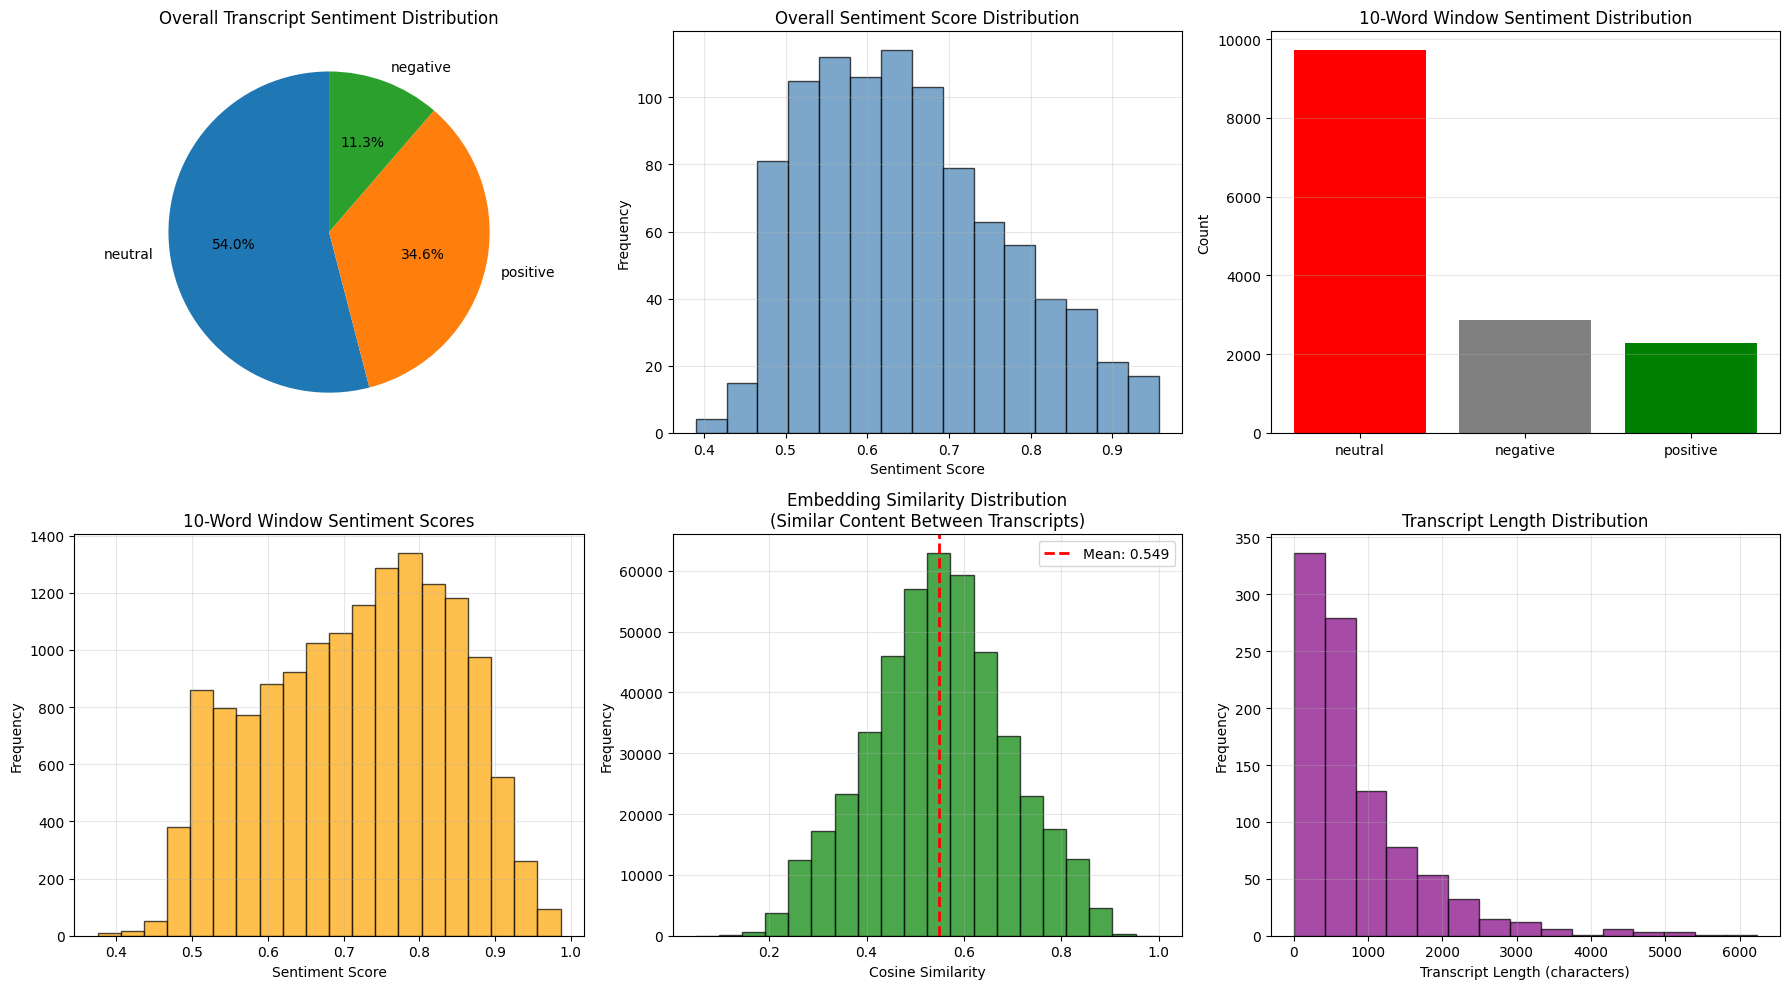

In [12]:
import matplotlib.pyplot as plt

# Create comprehensive visualization
if len(overall_df) > 0 and len(window_sentiment_df) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # 1. Overall Sentiment Distribution
    sentiment_dist = overall_df['sentiment_label'].value_counts()
    axes[0, 0].pie(sentiment_dist.values, labels=sentiment_dist.index, autopct='%1.1f%%', startangle=90)
    axes[0, 0].set_title('Overall Transcript Sentiment Distribution')
    
    # 2. Overall Sentiment Scores
    axes[0, 1].hist(overall_df['sentiment_score'], bins=15, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0, 1].set_xlabel('Sentiment Score')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Overall Sentiment Score Distribution')
    axes[0, 1].grid(alpha=0.3)
    
    # 3. Window-Level Sentiment Distribution
    window_sentiment_dist = window_sentiment_df['sentiment_label'].value_counts()
    axes[0, 2].bar(window_sentiment_dist.index, window_sentiment_dist.values, color=['red', 'gray', 'green'][:len(window_sentiment_dist)])
    axes[0, 2].set_ylabel('Count')
    axes[0, 2].set_title('10-Word Window Sentiment Distribution')
    axes[0, 2].grid(alpha=0.3, axis='y')
    
    # 4. Window Sentiment Scores Distribution
    axes[1, 0].hist(window_sentiment_df['sentiment_score'], bins=20, edgecolor='black', alpha=0.7, color='orange')
    axes[1, 0].set_xlabel('Sentiment Score')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('10-Word Window Sentiment Scores')
    axes[1, 0].grid(alpha=0.3)
    
    # 5. Overall Embedding Similarity Distribution
    if len(similarity_df) > 0:
        axes[1, 1].hist(similarity_df['cosine_similarity'], bins=20, edgecolor='black', alpha=0.7, color='green')
        axes[1, 1].axvline(similarity_df['cosine_similarity'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {similarity_df["cosine_similarity"].mean():.3f}')
        axes[1, 1].set_xlabel('Cosine Similarity')
        axes[1, 1].set_ylabel('Frequency')
        axes[1, 1].set_title('Embedding Similarity Distribution\n(Similar Content Between Transcripts)')
        axes[1, 1].legend()
        axes[1, 1].grid(alpha=0.3)
    
    # 6. Transcript Length Distribution
    axes[1, 2].hist(overall_df['transcript_length'], bins=15, edgecolor='black', alpha=0.7, color='purple')
    axes[1, 2].set_xlabel('Transcript Length (characters)')
    axes[1, 2].set_ylabel('Frequency')
    axes[1, 2].set_title('Transcript Length Distribution')
    axes[1, 2].grid(alpha=0.3)
    
    plt.tight_layout()
    
    # Save figure
    plot_path = ANALYSIS_OUTPUT_DIR / f"analysis_plots_{timestamp}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Visualization saved: {plot_path.name}")
    plt.show()


Generating sentiment progression plots...
Showing sentiment progression for 10 participants with >= 10 windows
✓ Sentiment progression plot saved: sentiment_progression_20260608_123601.png


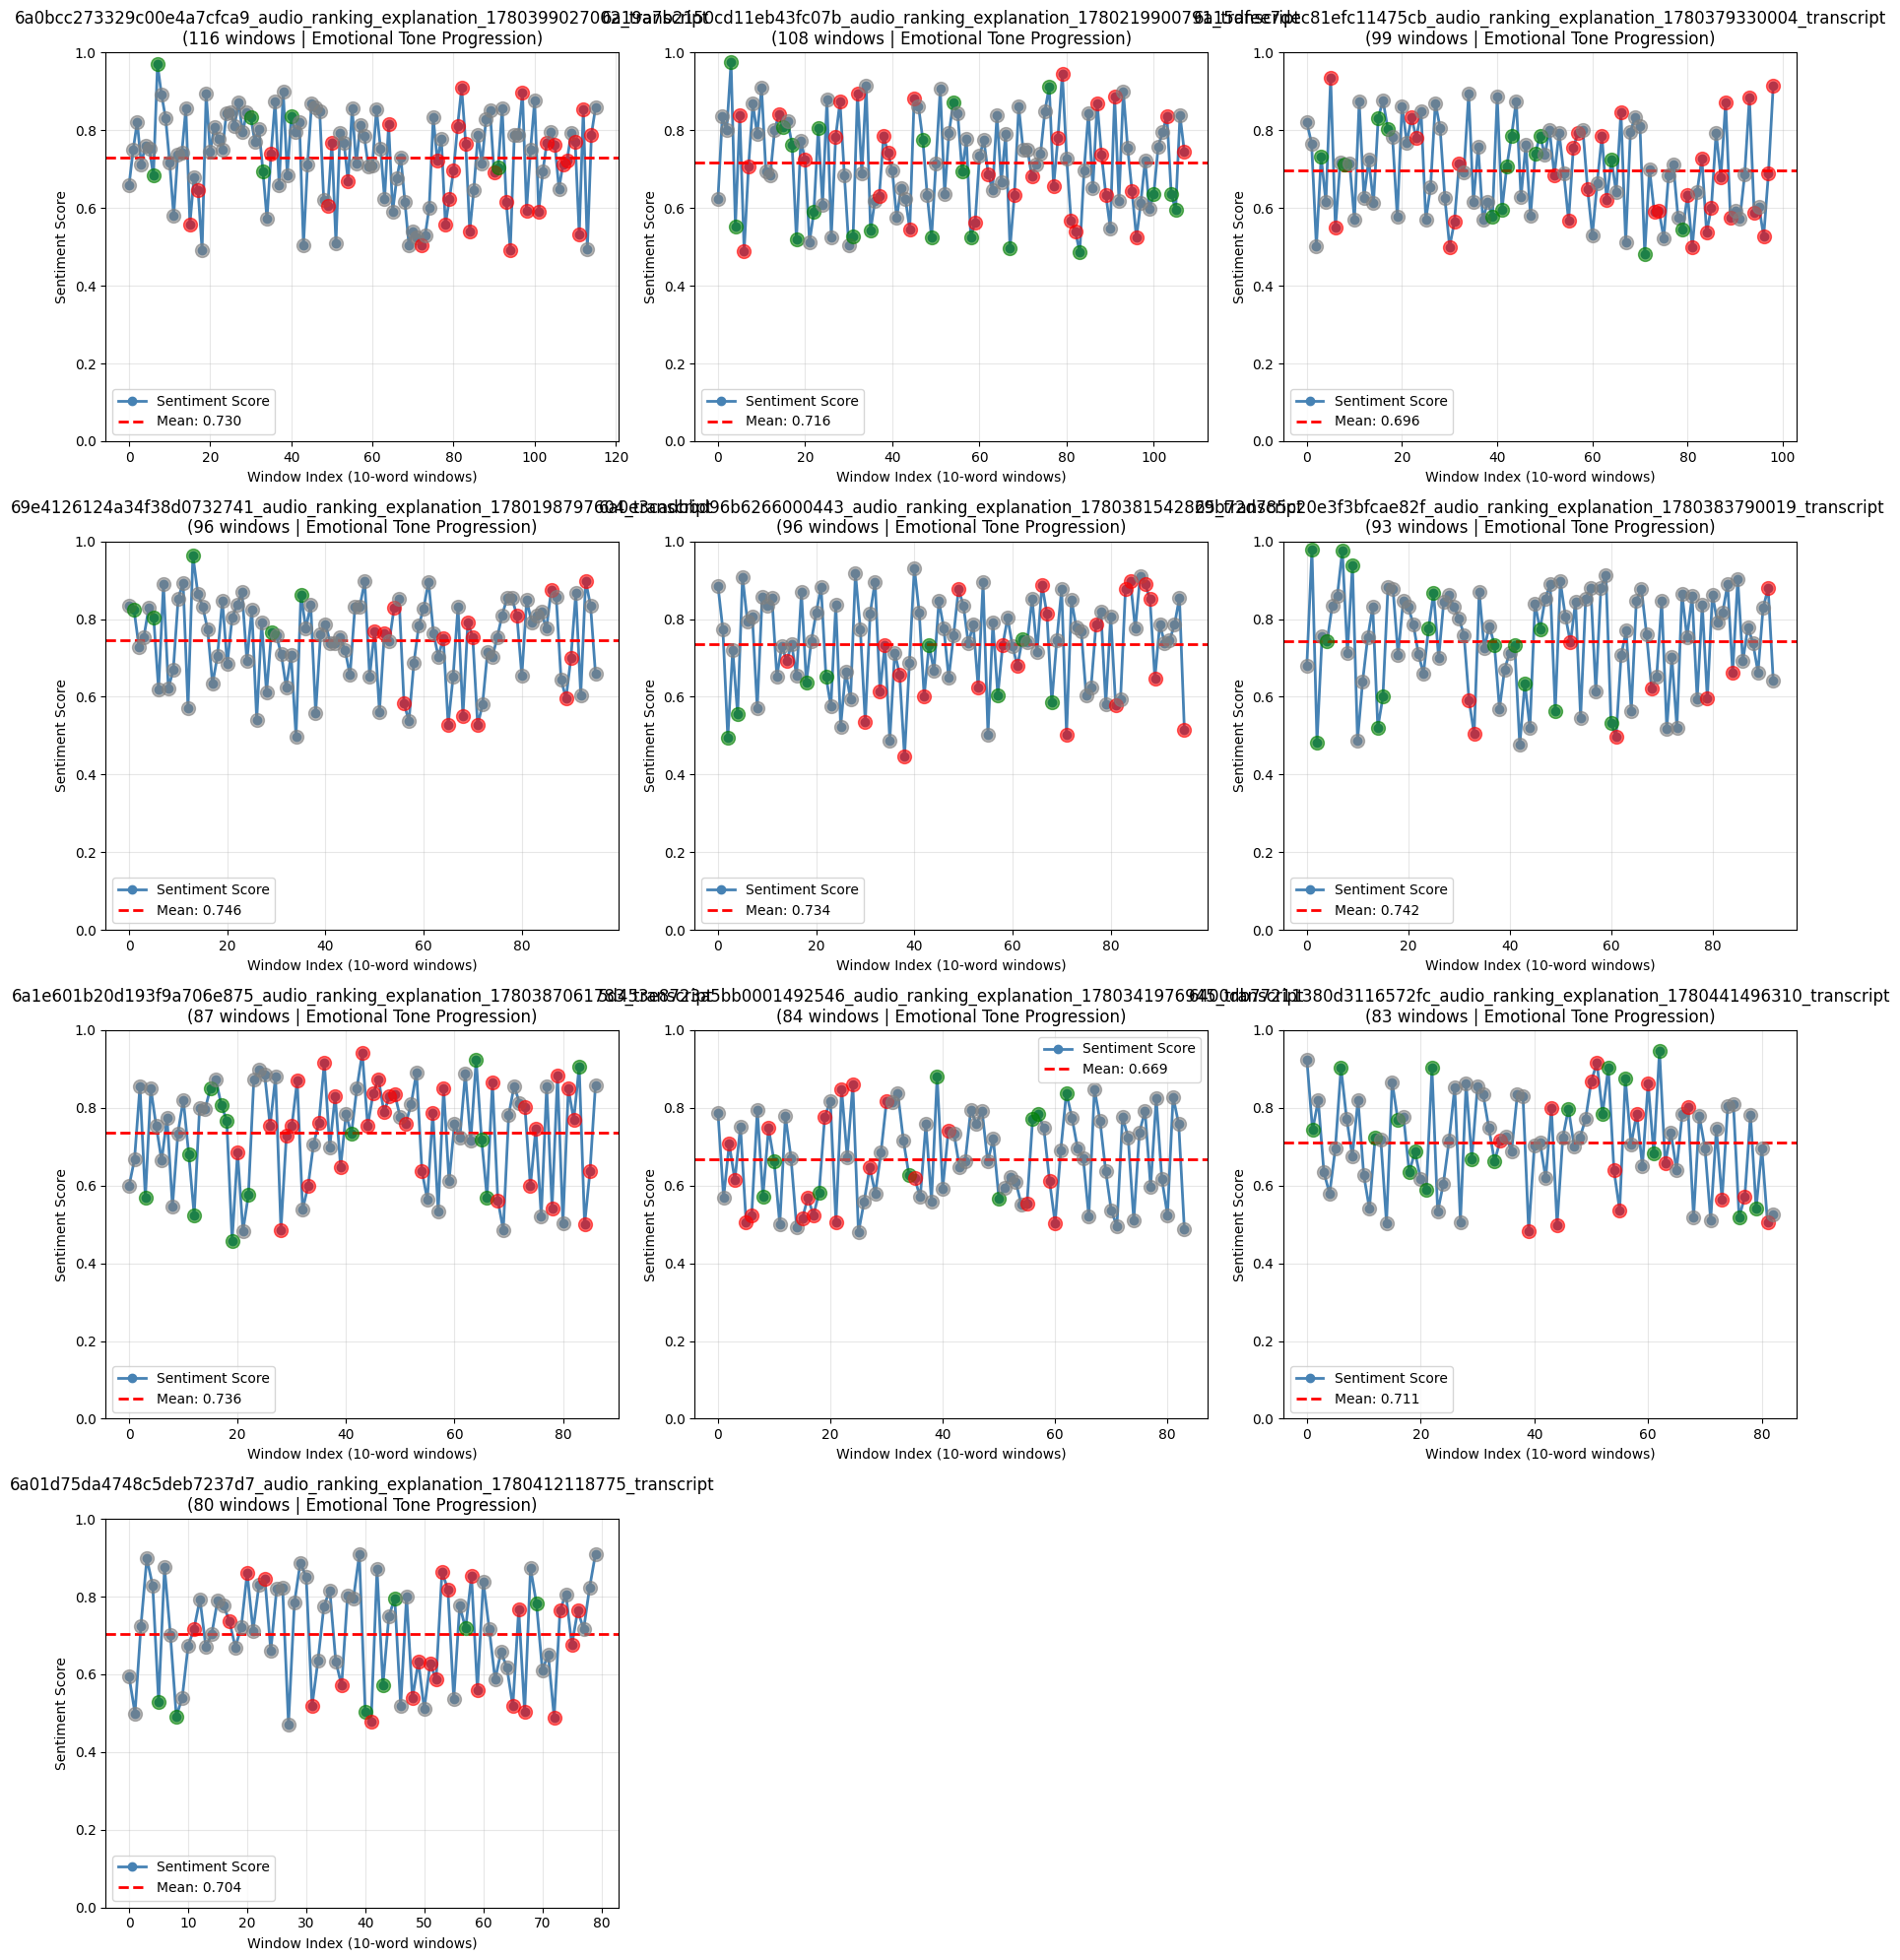


SENTIMENT PROGRESSION SUMMARY (5 Windows Minimum)

                                                                  json_file  num_windows  first_window_sentiment  last_window_sentiment  sentiment_change  mean_sentiment  sentiment_volatility  label_changes      trend
6a0bcc273329c00e4a7cfca9_audio_ranking_explanation_1780399027002_transcript          116                  0.6601                 0.8582            0.1982          0.7302                0.1142             45 Positive ↑
6a19a7b2150cd11eb43fc07b_audio_ranking_explanation_1780219900791_transcript          108                  0.6240                 0.7445            0.1205          0.7161                0.1243             59 Positive ↑
6a15dfee7dec81efc11475cb_audio_ranking_explanation_1780379330004_transcript           99                  0.8200                 0.9152            0.0952          0.6957                0.1169             45   Stable →
69e4126124a34f38d0732741_audio_ranking_explanation_1780198797604_transcript 

In [14]:
# Sentiment progression over time (through 10-word windows)
# Only for participants with >= 5 windows, max 5 participants
import matplotlib.pyplot as plt

numPlots = min(10, len(window_sentiment_df['json_file'].unique()))

print("\nGenerating sentiment progression plots...")

# Filter: only files with at least 5 windows
file_window_counts = window_sentiment_df['json_file'].value_counts()
valid_files = file_window_counts[file_window_counts >= 5].index.tolist()[:numPlots]  # Max 5

print(f"Showing sentiment progression for {len(valid_files)} participants with >= {numPlots} windows")

if len(valid_files) == 0:
    print("⚠ No participants with >= 5 windows found")
else:
    # Create subplots only for valid files
    num_files = len(valid_files)
    cols = min(3, num_files)
    rows = (num_files + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
    
    # Flatten axes for easier iteration
    if num_files == 1:
        axes = [axes]
    elif rows == 1:
        axes = axes.reshape(1, -1).flatten()
    elif cols == 1:
        axes = axes.reshape(-1, 1).flatten()
    else:
        axes = axes.flatten()
    
    for idx, file_id in enumerate(valid_files):
        file_data = window_sentiment_df[window_sentiment_df['json_file'] == file_id].sort_values('window_index')
        
        ax = axes[idx]
        
        # Plot sentiment scores over windows
        ax.plot(file_data['window_index'], file_data['sentiment_score'], 
                marker='o', linestyle='-', linewidth=2, markersize=6, color='steelblue', label='Sentiment Score')
        
        # Add sentiment label colors as background
        for i, (window_idx, sentiment_label, score) in enumerate(zip(file_data['window_index'], 
                                                                       file_data['sentiment_label'], 
                                                                       file_data['sentiment_score'])):
            if sentiment_label == 'negative':
                color = 'red'
            elif sentiment_label == 'positive':
                color = 'green'
            else:
                color = 'gray'
            ax.scatter(window_idx, score, color=color, s=100, alpha=0.6, zorder=3)
        
        # Add mean line
        mean_sentiment = file_data['sentiment_score'].mean()
        ax.axhline(y=mean_sentiment, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_sentiment:.3f}')
        
        ax.set_xlabel('Window Index (10-word windows)')
        ax.set_ylabel('Sentiment Score')
        ax.set_title(f'{file_id}\n({len(file_data)} windows | Emotional Tone Progression)')
        ax.grid(alpha=0.3)
        ax.legend(loc='best')
        ax.set_ylim(0, 1.0)
    
    # Hide extra subplots
    for idx in range(len(valid_files), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    
    # Save figure
    sentiment_progression_path = ANALYSIS_OUTPUT_DIR / f"sentiment_progression_{timestamp}.png"
    plt.savefig(sentiment_progression_path, dpi=300, bbox_inches='tight')
    print(f"✓ Sentiment progression plot saved: {sentiment_progression_path.name}")
    plt.show()
    
    # Create summary table of sentiment changes (only valid files)
    print("\n" + "="*80)
    print("SENTIMENT PROGRESSION SUMMARY (5 Windows Minimum)")
    print("="*80)
    
    progression_summary = []
    for file_id in valid_files:
        file_data = window_sentiment_df[window_sentiment_df['json_file'] == file_id].sort_values('window_index')
        
        scores = file_data['sentiment_score'].values
        first_sentiment = scores[0]
        last_sentiment = scores[-1]
        sentiment_change = last_sentiment - first_sentiment
        
        # Count sentiment label changes
        labels = file_data['sentiment_label'].values
        label_changes = sum(1 for i in range(len(labels)-1) if labels[i] != labels[i+1])
        
        progression_summary.append({
            'json_file': file_id,
            'num_windows': len(file_data),
            'first_window_sentiment': round(first_sentiment, 4),
            'last_window_sentiment': round(last_sentiment, 4),
            'sentiment_change': round(sentiment_change, 4),
            'mean_sentiment': round(file_data['sentiment_score'].mean(), 4),
            'sentiment_volatility': round(file_data['sentiment_score'].std(), 4),
            'label_changes': label_changes,
            'trend': 'Positive ↑' if sentiment_change > 0.1 else ('Negative ↓' if sentiment_change < -0.1 else 'Stable →')
        })
    
    progression_df = pd.DataFrame(progression_summary)
    print("\n" + progression_df.to_string(index=False))
    
    # Save to CSV
    progression_csv = ANALYSIS_OUTPUT_DIR / f"sentiment_progression_summary_{timestamp}.csv"
    progression_df.to_csv(progression_csv, index=False, encoding='utf-8')
    print(f"\n✓ Progression summary saved: {progression_csv.name}")